In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Cell 2: Inspect Missing Values

In [3]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Handle Categorical Missing Values

In [4]:
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

Handle Numerical Missing Values

In [5]:
if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

if 'GarageYrBlt' in df.columns and 'YearBuilt' in df.columns:
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

Remove Outliers

In [6]:
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

Export Clean Data

In [7]:
df.to_csv('house_prices_cleaned.csv', index=False)
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


Verify Missing Values Count Table

In [8]:
null_counts = df.isnull().sum()
null_table = pd.DataFrame({'Column': null_counts.index, 'Remaining Missing': null_counts.values})
display(null_table[null_table['Remaining Missing'] > 0])

,Column,Remaining Missing
25,MasVnrType,872
42,Electrical,1


Categorical Encoding & Display Table

In [9]:
df = pd.get_dummies(df, drop_first=True)
display(df.head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


Scale Numerical Features & Display Table

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
df[num_features] = scaler.fit_transform(df[num_features])

display(df[num_features].head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,-1.730311,0.073426,-0.232605,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,...,0.357973,-0.750831,0.225982,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,-1.601578,0.138375
1,-1.727939,-0.871868,0.466313,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,...,-0.056795,1.627328,-0.708304,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,-0.490155,-0.614427
2,-1.725566,0.073426,-0.092822,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,...,0.640770,-0.750831,-0.065025,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,0.991743,0.138375
3,-1.723193,0.309749,-0.465578,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,...,0.801022,-0.750831,-0.172238,4.089589,-0.11642,-0.270407,-0.063709,-0.087748,-1.601578,-1.367230
4,-1.720820,0.073426,0.652691,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,...,1.715398,0.781406,0.578253,-0.359603,-0.11642,-0.270407,-0.063709,-0.087748,2.103167,0.138375


Export Final Processed Table & Display

In [11]:
df.to_csv('house_prices_ready.csv', index=False)
display(df.head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730311,0.073426,-0.232605,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,...,False,False,False,False,True,False,False,False,True,False
1,-1.727939,-0.871868,0.466313,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,...,False,False,False,False,True,False,False,False,True,False
2,-1.725566,0.073426,-0.092822,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,...,False,False,False,False,True,False,False,False,True,False
3,-1.723193,0.309749,-0.465578,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,...,False,False,False,False,True,False,False,False,False,False
4,-1.720820,0.073426,0.652691,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,...,False,False,False,False,True,False,False,False,True,False


Plot Distribution of Target Variable

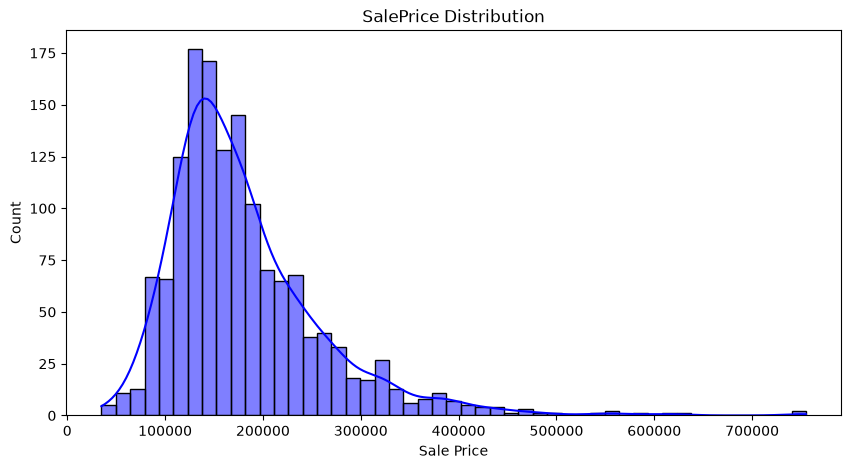

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('SalePrice Distribution')
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.show()

lot Outliers before and after Cleaning (GrLivArea vs SalePrice)

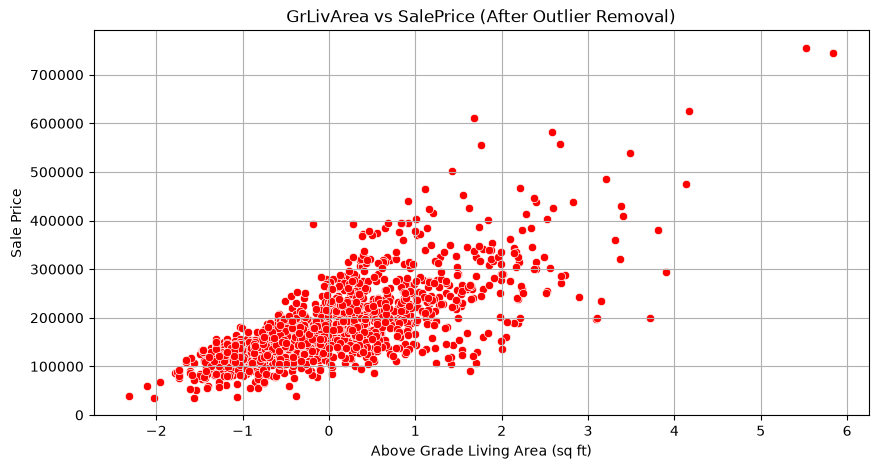

In [13]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, color='red')
plt.title('GrLivArea vs SalePrice (After Outlier Removal)')
plt.xlabel('Above Grade Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()

Correlation Heatmap for Top Numerical Features

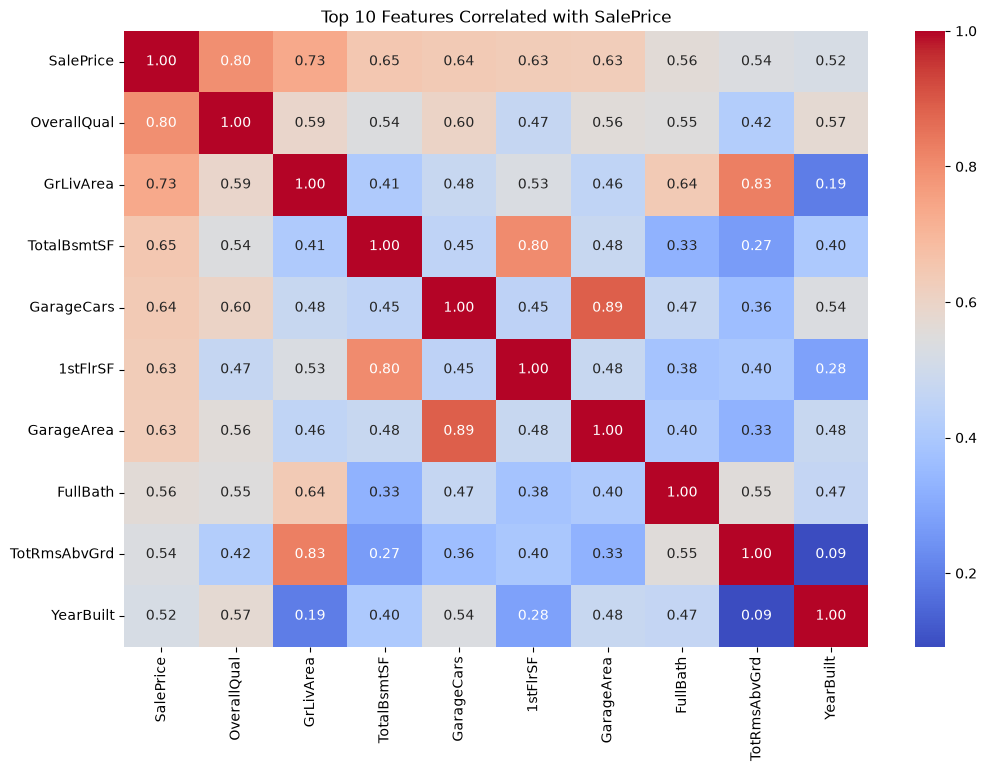

In [14]:
plt.figure(figsize=(12, 8))
top_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10).index
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top 10 Features Correlated with SalePrice')
plt.show()

Count Plot for Categorical Feature Examples

C:\Users\DELL\AppData\Local\Temp\ipykernel_25800\4154707164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OverallQual', data=df, ax=axes[0], palette='viridis')
C:\Users\DELL\AppData\Local\Temp\ipykernel_25800\4154707164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1], palette='viridis')


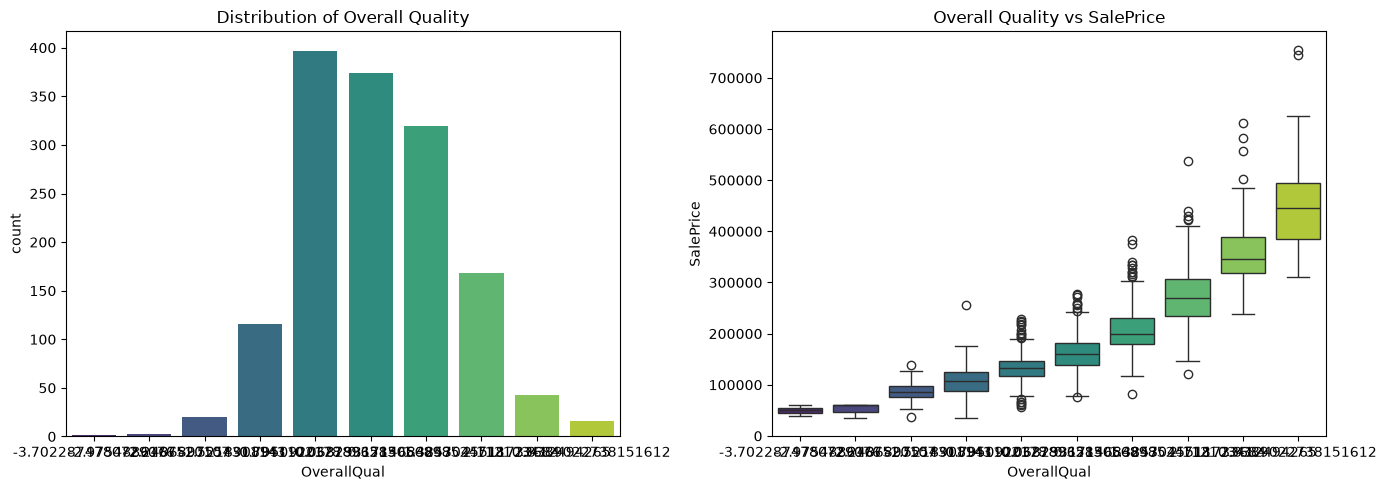

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='OverallQual', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Overall Quality')

sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Overall Quality vs SalePrice')

plt.tight_layout()
plt.show()

Missing Values Heatmap (Before vs After)

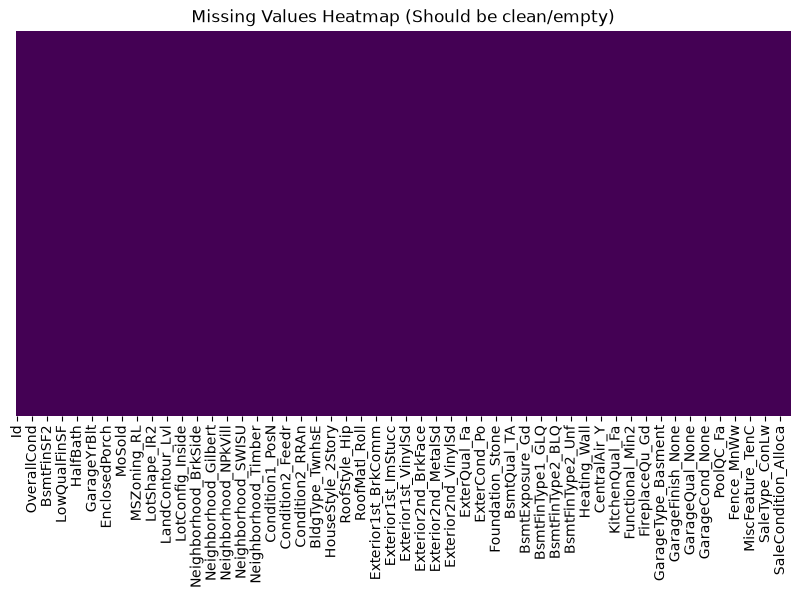

In [16]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Should be clean/empty)')
plt.show()